In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import r2_score

### Load data

In [30]:
data = np.load("fit_results.npz")
data_dict = {key: data[key] for key in data.files}
data_dict

{'e_disp_ref': array([-7.3749069e+01, -6.0493610e+01, -4.9847046e+01, ...,
        -1.7761080e-01, -1.1045760e-01, -7.1630083e-02], dtype=float32),
 'e_disp_xdm_init': array([-5.8070422e+02, -3.5089792e+02, -2.1948267e+02, ...,
        -1.1612475e-01, -7.1125671e-02, -4.5582421e-02], dtype=float32),
 'e_disp_xdm_final': array([-5.26391907e+01, -4.60952454e+01, -4.00974503e+01, ...,
        -1.15863904e-01, -7.10301995e-02, -4.55441363e-02], dtype=float32),
 'a1': array(0.66412437),
 'a2': array(0.89044476)}

### Plot

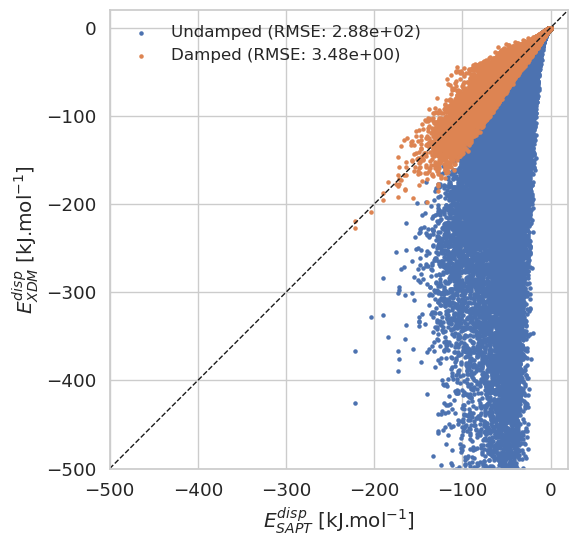

In [ ]:
sns.set(style="whitegrid", font_scale=1.2)

def metrics(y_ref, y_pred):
    err = y_pred - y_ref
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    mse = np.mean(err)  # mean signed error (bias)
    tau, _ = kendalltau(y_ref, y_pred)
    rho, _ = spearmanr(y_ref, y_pred)
    r2 = r2_score(y_ref, y_pred)
    return rmse, mae, mse, tau, rho, r2

x = data_dict["e_disp_ref"]
y_init = np.asarray(data_dict["e_disp_xdm_init"])
y_final = data_dict["e_disp_xdm_final"]

rmse_i, mae_i, mse_i, tau_i, rho_i, r2_i = metrics(x, y_init)
rmse_f, mae_f, mse_f, tau_f, rho_f, r2_f = metrics(x, y_final)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y_init, s=5, alpha=1, rasterized=True, label="Undamped (RMSE: {:.2e})".format(rmse_i))
ax.scatter(x, y_final, s=5, alpha=1, rasterized=True, label="Damped (RMSE: {:.2e})".format(rmse_f))

lims = [-500, 20]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(r"$E_{SAPT}^{disp}$ [kJ.mol$^{-1}$]")
ax.set_ylabel(r"$E_{XDM}^{disp}$ [kJ.mol$^{-1}$]")
ax.set_aspect("equal", adjustable="box")

ax.legend(frameon=False, loc="upper left", fontsize=12)
ax.grid(True)

plt.tight_layout()
plt.savefig("fit_results.pdf", dpi=1200, bbox_inches="tight")
plt.show()